In [1]:
import sys
sys.path.insert(0, '..')

from utils.preprocessing import preprocess_data
from utils.evaluation import (
    load_and_evaluate_cnnlstm_model,
)
import joblib
from withProperties.experiment_logger import save_cross_dataset_evaluation
from sklearn.metrics import classification_report

In [2]:
df_cicids2017 = preprocess_data("../data/CICIDS2017/wednesday_labeled.tsv")
df_ciciot2023 = preprocess_data("../data/CICIoT2023/ciciot2023_labeled_conn.tsv")

In [3]:
label_column = "label"

df_cicids2017 = df_cicids2017[df_cicids2017["label"].isin(["DOS_HTTP_FLOOD"] + ["BENIGN"])]
X_cicids = df_cicids2017.drop(columns=[label_column])
y_cicids = df_cicids2017[label_column]

X_ciciot = df_ciciot2023.drop(columns=[label_column])
y_ciciot = df_ciciot2023[label_column]

print("CICIDS test shape:", X_cicids.shape)
print("CICIoT test shape:", X_ciciot.shape)

CICIDS test shape: (481829, 7)
CICIoT test shape: (1850844, 7)


Evaluation for CICIoT2023-trained CNNLSTM tested on CICIDS2017:

=== CICIoT2023-trained CNNLSTM tested on CICIDS2017 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.7390    0.9237    0.8211    327060
DOS_HTTP_FLOOD     0.6584    0.3106    0.4220    154769

      accuracy                         0.7268    481829
     macro avg     0.6987    0.6172    0.6216    481829
  weighted avg     0.7131    0.7268    0.6929    481829


=== Per-Label Accuracy ===

BENIGN: 0.9237
DOS_HTTP_FLOOD: 0.3106


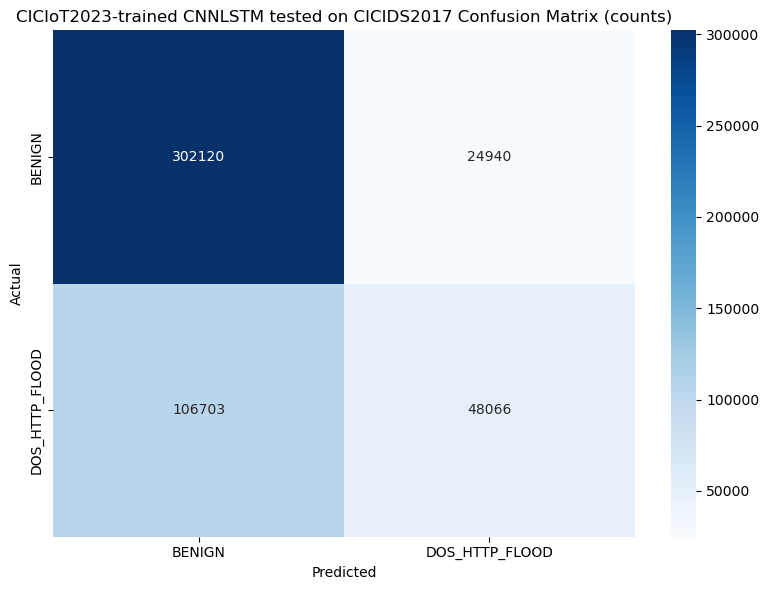

Cross-dataset evaluation saved to: ..\experiments\20260405_205836_2props\cross_eval_on_cicids2017.json


WindowsPath('../experiments/20260405_205836_2props/cross_eval_on_cicids2017.json')

In [7]:
from withProperties.experiment_logger import save_cross_dataset_evaluation
from sklearn.metrics import classification_report

# Load CICIoT2023 model and evaluate on CICIDS2017
results1 = load_and_evaluate_cnnlstm_model(
    joblib_path="models/cnnlstm_property_ciciot2023.joblib",
    X=X_cicids,
    y_true=y_cicids,
    model_name="CICIoT2023-trained CNNLSTM tested on CICIDS2017"
)

# Extract experiment folder from model and save cross-dataset evaluation
model_ciciot = joblib.load("models/cnnlstm_property_ciciot2023.joblib")
experiment_folder_ciciot = model_ciciot["experiment_folder"]

# Use the classification report already computed by evaluate_model()
save_cross_dataset_evaluation(
    experiment_folder=experiment_folder_ciciot,
    tested_on="cicids2017",
    accuracy=results1["accuracy"],
    classification_report=results1["classification_report"],
    confusion_matrix=results1["confusion_matrix"],
    experiments_dir="./../experiments"
)

Evaluation for CICIDS2017-trained CNNLSTM tested on CICIoT2023:

=== CICIDS2017-trained CNNLSTM tested on CICIoT2023 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.2013    0.9692    0.3334    342255
DOS_HTTP_FLOOD     0.9480    0.1276    0.2250   1508589

      accuracy                         0.2833   1850844
     macro avg     0.5747    0.5484    0.2792   1850844
  weighted avg     0.8099    0.2833    0.2450   1850844


=== Per-Label Accuracy ===

BENIGN: 0.9692
DOS_HTTP_FLOOD: 0.1276


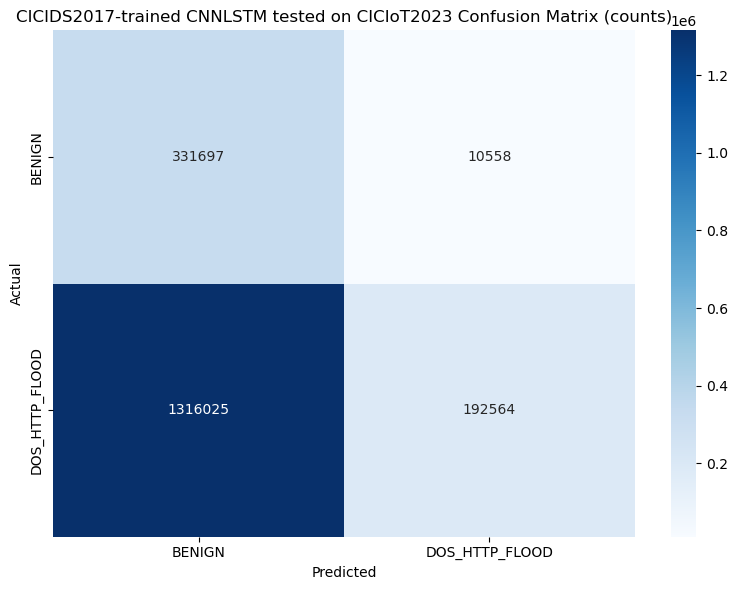

Cross-dataset evaluation saved to: ..\experiments\20260405_210240_2props\cross_eval_on_ciciot2023.json


WindowsPath('../experiments/20260405_210240_2props/cross_eval_on_ciciot2023.json')

In [8]:
# Load CICIDS2017 model and evaluate on CICIoT2023
results2 = load_and_evaluate_cnnlstm_model(
    joblib_path="models/cnnlstm_property_cicids2017.joblib",
    X=X_ciciot,
    y_true=y_ciciot,
    model_name="CICIDS2017-trained CNNLSTM tested on CICIoT2023"
)

# Extract experiment folder from model and save cross-dataset evaluation
model_cicids = joblib.load("models/cnnlstm_property_cicids2017.joblib")
experiment_folder_cicids = model_cicids["experiment_folder"]

# Use the classification report already computed by evaluate_model()
save_cross_dataset_evaluation(
    experiment_folder=experiment_folder_cicids,
    tested_on="ciciot2023",
    accuracy=results2["accuracy"],
    classification_report=results2["classification_report"],
    confusion_matrix=results2["confusion_matrix"],
    experiments_dir="./../experiments"
)